# Target Credentialing: Wnt Pathway & ERG/AR in Cancer

A demonstration of target credentialing methods using public functional genomic (DepMap CRISPR
dependency) and patient genomic (cBioPortal MSK-IMPACT, TCGA PRAD) data.

Two independent target hypotheses are evaluated:

- **Wnt pathway**: does Wnt-activating mutation status (APC / CTNNB1 / RNF43) predict CRISPR
  dependency on Wnt-pathway genes, and how prevalent are these mutations outside colorectal
  cancer — is there an indication-expansion opportunity? This analysis draws on both functional
  genomics (cell-line dependency data) and patient genomics (real-world mutation prevalence).
- **ERG/AR**: does TMPRSS2-ERG fusion status co-occur with AR-pathway alteration (AR-V7
  presence, AR Score) in prostate cancer patients, and what does that suggest about
  patient-stratification or combination strategy? This analysis draws on patient genomics alone.

## Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

DATA_DIR = Path("../data")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Categorical palette (fixed slot order, not cycled).
COLOR_WT = "#2a78d6"       # slot 1 (blue)
COLOR_MUTANT = "#eb6834"   # slot 2 (orange)
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": INK_MUTED,
    "axes.labelcolor": INK_PRIMARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_SECONDARY,
    "ytick.color": INK_SECONDARY,
    "grid.color": GRID,
    "font.size": 10,
})

TARGET_GENES = ["APC", "CTNNB1", "RNF43", "TCF7L2", "AXIN1", "AXIN2", "ERG", "AR", "TMPRSS2"]

## Data Sources

- **DepMap** (Broad Institute): CRISPR dependency (Chronos) scores and precomputed mutation
  classifications (damaging, hotspot) for a nine-gene panel (APC, CTNNB1, RNF43, TCF7L2, AXIN1,
  AXIN2, ERG, AR, TMPRSS2) across cancer cell lines. Cell lines are identified by `depmap_id`.
- **MSK-IMPACT Clinical Sequencing Cohort** (cBioPortal): a large, real-world clinical sequencing
  dataset spanning many cancer types (48,179 patients). Used for the Wnt-pathway analysis's
  patient-genomics component — a large and clinically representative population to address prevalence *across* cancer types.
- **TCGA Prostate Adenocarcinoma (Cell 2015)** (cBioPortal): a curated cohort of 333 prostate
  cancer patients with deep molecular characterization, including a curated fusion-subtype field
  and AR-pathway variables (AR Score, AR-V7 presence). Used for the ERG/AR analysis for prostate-specific characterization.

**Note on data sources:** the Wnt-pathway analysis uses MSK-IMPACT (a large, multi-cancer-type cohort) because it asks a prevalence question spanning many indications. The ERG/AR analysis uses TCGA PRAD instead, since it needs prostate-specific molecular depth (AR Score, AR-V7, a validated fusion subtype) that MSK-IMPACT doesn't provide.

## Wnt Pathway: Does Mutation Status Predict Dependency, and Where Does It Matter Most?

Load the three DepMap files — CRISPR dependency scores, damaging-mutation calls,
and hotspot-mutation calls — and confirm the cell-line identifiers line up across all three
before joining them.

In [2]:
crispr = pd.read_csv(DATA_DIR / "CRISPR_(DepMap_Public_26Q1+Score,_Chronos)_subsetted.csv")
damaging = pd.read_csv(DATA_DIR / "Damaging_Mutations_(Public_26Q1)_subsetted.csv")
hotspot = pd.read_csv(DATA_DIR / "Hotspot_Mutations_(Public_26Q1)_subsetted.csv")

print(f"CRISPR (Chronos):     {crispr.shape[0]:,} cell lines x {crispr.shape[1]} cols")
print(f"Damaging mutations:   {damaging.shape[0]:,} cell lines x {damaging.shape[1]} cols")
print(f"Hotspot mutations:    {hotspot.shape[0]:,} cell lines x {hotspot.shape[1]} cols")
assert set(crispr["depmap_id"]).issubset(set(damaging["depmap_id"]))
assert set(crispr["depmap_id"]).issubset(set(hotspot["depmap_id"]))
print("\nAll CRISPR-screened lines present in both mutation matrices — OK.")

CRISPR (Chronos):     1,208 cell lines x 16 cols
Damaging mutations:   1,968 cell lines x 16 cols
Hotspot mutations:    1,968 cell lines x 11 cols

All CRISPR-screened lines present in both mutation matrices — OK.


### Defining a Wnt-Activating Mutation

| Gene | Definition | Source column |
|---|---|---|
| **APC** | Truncating/nonsense mutations only | `Damaging_Mutations` matrix, `APC` |
| **CTNNB1** | Exon 3 hotspot mutations (canonical degron codons, e.g. S33/S37/S45/T41) | `Hotspot_Mutations` matrix, `CTNNB1` |
| **RNF43** | Truncating mutations only | `Damaging_Mutations` matrix, `RNF43` |

**Implementation note / limitation:** the DepMap "subsetted" downloads are gene-by-cell-line
count matrices, not variant-level calls — there is no HGVSp/codon-position field available to
independently re-filter for exon 3 degron codons. Use the DepMap
classification: the `Damaging_Mutations` matrix already restricts to LoF-type consequences
(nonsense, frameshift, splice-site — i.e. truncating, not missense), which matches the APC/RNF43
criteria as stated. The `Hotspot_Mutations` matrix restricts to DepMap's hotspot-database calls,
which for CTNNB1 are dominated by the exon 3 degron codons but are not independently verified
against the specific S33/S37/S45/T41 list here. This is a reasonable proxy.

Each matrix cell is a **count** of qualifying mutations (0, 1, or 2) rather than a binary flag;
binarize as count > 0. A cell line is flagged **Wnt-activating** if it is positive for *any*
of the three criteria.

In [3]:
wnt_components = (
    damaging[["depmap_id", "APC", "RNF43"]]
    .rename(columns={"APC": "APC_damaging_n", "RNF43": "RNF43_damaging_n"})
    .merge(
        hotspot[["depmap_id", "CTNNB1"]].rename(columns={"CTNNB1": "CTNNB1_hotspot_n"}),
        on="depmap_id",
    )
)

wnt_components["APC_flag"] = wnt_components["APC_damaging_n"] > 0
wnt_components["RNF43_flag"] = wnt_components["RNF43_damaging_n"] > 0
wnt_components["CTNNB1_flag"] = wnt_components["CTNNB1_hotspot_n"] > 0
wnt_components["wnt_activating"] = (
    wnt_components["APC_flag"] | wnt_components["RNF43_flag"] | wnt_components["CTNNB1_flag"]
)

print("Wnt-activating flag, all 1,968 DepMap lines with mutation calls:")
print(wnt_components["wnt_activating"].value_counts().rename({True: "mutant", False: "wild-type"}))
print("\nBy individual criterion (not mutually exclusive):")
for col in ["APC_flag", "RNF43_flag", "CTNNB1_flag"]:
    print(f"  {col}: {wnt_components[col].sum()} lines")

Wnt-activating flag, all 1,968 DepMap lines with mutation calls:
wnt_activating
wild-type    1790
mutant        178
Name: count, dtype: int64

By individual criterion (not mutually exclusive):
  APC_flag: 108 lines
  RNF43_flag: 45 lines
  CTNNB1_flag: 45 lines


### Functional Genomics: Cell-Line Dependency by Mutation Status

Merge Chronos dependency scores for CTNNB1, TCF7L2, AXIN1, and AXIN2 with the Wnt-activating
flag above, restricted to the 1,208 CRISPR-screened cell lines. Compare
Wnt-activating-mutant vs. wild-type dependency with a two-sided Mann-Whitney U test per gene,
Benjamini-Hochberg FDR-corrected across the four genes tested simultaneously.

In [4]:
DEP_GENES = ["CTNNB1", "TCF7L2", "AXIN1", "AXIN2"]

merged = crispr.merge(wnt_components[["depmap_id", "wnt_activating"]], on="depmap_id", how="inner")
assert merged["wnt_activating"].notna().all()

n_mut = int(merged["wnt_activating"].sum())
n_wt = int((~merged["wnt_activating"]).sum())
print(f"CRISPR-screened lines: {len(merged):,} total  |  {n_mut} Wnt-activating-mutant  |  {n_wt} wild-type")

CRISPR-screened lines: 1,208 total  |  127 Wnt-activating-mutant  |  1081 wild-type


In [5]:
results = []
for gene in DEP_GENES:
    mut_scores = merged.loc[merged["wnt_activating"], gene].dropna()
    wt_scores = merged.loc[~merged["wnt_activating"], gene].dropna()

    u_stat, p_val = stats.mannwhitneyu(mut_scores, wt_scores, alternative="two-sided")
    # Rank-biserial effect size: r > 0 means mutant scores tend to be LOWER (more negative,
    # i.e. MORE dependent) than wild-type; r < 0 means mutant scores tend to be HIGHER (less
    # dependent). Verified against scipy's U-statistic convention (U small when sample 1 < sample 2).
    r_rb = 1 - (2 * u_stat) / (len(mut_scores) * len(wt_scores))

    results.append({
        "gene": gene,
        "n_mutant": len(mut_scores),
        "n_wt": len(wt_scores),
        "median_mutant": mut_scores.median(),
        "median_wt": wt_scores.median(),
        "median_diff (mutant - wt)": mut_scores.median() - wt_scores.median(),
        "rank_biserial_r": r_rb,
        "p_value": p_val,
    })

results_df = pd.DataFrame(results)
reject, p_adj, _, _ = multipletests(results_df["p_value"], method="fdr_bh")
results_df["p_adj_BH"] = p_adj
results_df["significant_FDR05"] = reject
results_df = results_df.sort_values("p_adj_BH").reset_index(drop=True)
results_df

,gene,n_mutant,n_wt,median_mutant,median_wt,median_diff (mutant - wt),rank_biserial_r,p_value,p_adj_BH,significant_FDR05
0,CTNNB1,127,1081,-0.879325,-0.127692,-0.751633,0.700875,2.821367e-38,1.128547e-37,True
1,TCF7L2,127,1081,-0.451412,-0.033995,-0.417417,0.566397,1.406385e-25,2.812770e-25,True
2,AXIN2,127,1081,-0.043357,-0.018002,-0.025355,0.136000,1.207245e-02,1.609660e-02,True
3,AXIN1,127,1081,0.060872,0.040660,0.020212,-0.033863,5.320477e-01,5.320477e-01,False


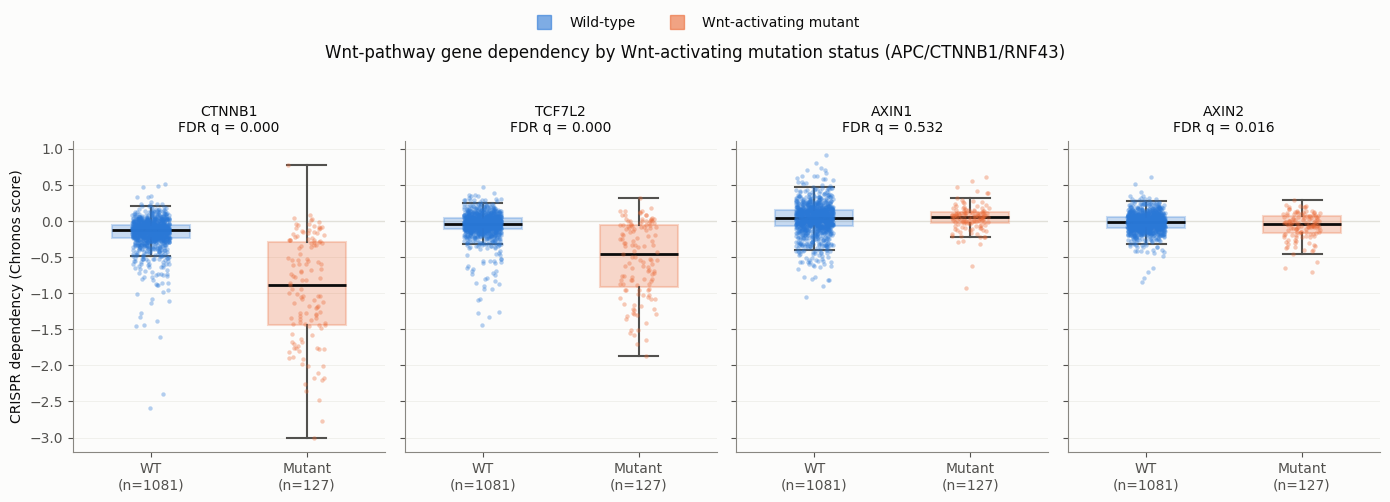

In [6]:
fig, axes = plt.subplots(1, len(DEP_GENES), figsize=(14, 4.5), sharey=True)

for ax, gene in zip(axes, DEP_GENES):
    mut_scores = merged.loc[merged["wnt_activating"], gene].dropna()
    wt_scores = merged.loc[~merged["wnt_activating"], gene].dropna()

    bp = ax.boxplot(
        [wt_scores, mut_scores],
        positions=[0, 1],
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color=INK_PRIMARY, linewidth=2),
        boxprops=dict(linewidth=1.5),
        whiskerprops=dict(linewidth=1.5, color=INK_SECONDARY),
        capprops=dict(linewidth=1.5, color=INK_SECONDARY),
    )
    for patch, color in zip(bp["boxes"], [COLOR_WT, COLOR_MUTANT]):
        patch.set_facecolor(color)
        patch.set_alpha(0.25)
        patch.set_edgecolor(color)

    rng = np.random.default_rng(0)
    for x, scores, color in zip([0, 1], [wt_scores, mut_scores], [COLOR_WT, COLOR_MUTANT]):
        jitter = rng.uniform(-0.12, 0.12, size=len(scores))
        ax.scatter(x + jitter, scores, s=10, color=color, alpha=0.35, linewidths=0, zorder=3)

    row = results_df.set_index("gene").loc[gene]
    ax.set_title(f"{gene}\nFDR q = {row['p_adj_BH']:.3f}", fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"WT\n(n={n_wt})", f"Mutant\n(n={n_mut})"])
    ax.axhline(0, color=GRID, linewidth=1, zorder=0)
    ax.grid(axis="y", linewidth=0.5, alpha=0.6)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("CRISPR dependency (Chronos score)")
fig.suptitle(
    "Wnt-pathway gene dependency by Wnt-activating mutation status (APC/CTNNB1/RNF43)",
    fontsize=12, y=1.03,
)

handles = [
    plt.Line2D([0], [0], marker="s", linestyle="", markerfacecolor=COLOR_WT, markeredgecolor=COLOR_WT, alpha=0.6, markersize=10, label="Wild-type"),
    plt.Line2D([0], [0], marker="s", linestyle="", markerfacecolor=COLOR_MUTANT, markeredgecolor=COLOR_MUTANT, alpha=0.6, markersize=10, label="Wnt-activating mutant"),
]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "wnt_dependency_by_gene.png", dpi=300, bbox_inches="tight")
plt.show()

### Result: CTNNB1 and TCF7L2 Dependency Track with Mutation Status

Comparison group: **127 Wnt-activating-mutant vs. 1,081 wild-type** CRISPR-screened cell lines
(pan-cancer, not restricted to any lineage) — a well-powered comparison.

| Gene | Median Δ (mutant − WT) | Direction | FDR q | Significant (q<0.05) |
|---|---|---|---|---|
| **CTNNB1** | −0.75 | mutant lines more dependent | 1.1×10⁻³⁷ | Yes |
| **TCF7L2** | −0.42 | mutant lines more dependent | 2.8×10⁻²⁵ | Yes |
| **AXIN2** | −0.03 | mutant lines more dependent | 0.016 | Yes |
| **AXIN1** | +0.02 | no consistent direction | 0.53 | No |

**Interpretation:**

- **CTNNB1 and TCF7L2** show large, highly significant shifts toward increased dependency
  (more negative Chronos scores) in Wnt-activating-mutant lines — cell lines carrying an
  APC/CTNNB1/RNF43-activating mutation are more reliant on continued CTNNB1 and TCF7L2 activity
  for fitness than wild-type lines. This is the expected on-pathway signal: these are direct
  downstream effectors of activated Wnt/β-catenin signaling, so mutation-driven pathway
  activation creating dependency on them is mechanistically consistent, not just statistically
  significant.
- **AXIN2** shows a small but FDR-significant shift in the same direction (more dependent in
  mutants). The effect size is modest (rank-biserial r = 0.14 vs. 0.70 for CTNNB1) — real
  signal, but far weaker than the CTNNB1/TCF7L2 effect. AXIN2 is itself a Wnt-pathway negative
  feedback target, so a weak dependency signal here is plausible but should be treated as
  secondary to the CTNNB1/TCF7L2 result.
- **AXIN1** shows no significant association (q = 0.53) and no consistent direction — on this
  data, it does not support a dependency hypothesis.

  *On the AXIN1/AXIN2 asymmetry specifically*: AXIN1 and AXIN2 are documented to have partial
  functional redundancy as Wnt-pathway scaffold proteins (both nucleate the APC/GSK3β/CK1
  β-catenin destruction complex), so it is biologically plausible that AXIN2 — which is itself a
  Wnt-responsive transcriptional target and typically the more dynamically-regulated paralog in
  epithelial tissue — carries more of the dependency signal while AXIN1 is functionally
  buffered/compensated by AXIN2 in these lines. This is offered as **one plausible interpretation
  worth further investigation** (e.g. checking relative AXIN1/AXIN2 expression across the mutant
  lines, or co-dependency with AXIN2), not a conclusion this dataset can establish — the current
  analysis has no expression or knockout-epistasis data to confirm redundancy is the actual
  mechanism, and the null AXIN1 result could equally reflect assay noise, low AXIN1 essentiality
  genome-wide, or no true biological relationship at all.

**Credentialing read (functional genomics only):** CTNNB1 and TCF7L2 are functional-genomics-
supported; AXIN2 weakly so; AXIN1 is not. This is one of two evidence lines for the Wnt-pathway
target hypothesis — the patient-genomics prevalence analysis follows.

### Patient Genomics: How Common Are These Mutations, and Where?

**Methodology:**

1. **Patient deduplication.** MSK-IMPACT has 54,331 samples across 48,179 patients (not 1:1) —
   some patients were sequenced more than once (different timepoints/panel versions). We
   deduplicate to **one sample per patient**, keeping the sample with the **highest
   `SAMPLE_COVERAGE`** (ties broken by first-occurrence) as the more reliable mutation call
   source. This yields an analysis unit of **48,179 patients** (one row each).
2. **Wnt-activating flag on MSK-IMPACT**, applying the same criteria defined above directly to
   variant-level MAF data (a more direct test than DepMap's pre-aggregated proxy, since MSK's
   mutation file includes `Variant_Classification` and codon position):
   - APC / RNF43: truncating classes — `Nonsense_Mutation`, `Frame_Shift_Del`,
     `Frame_Shift_Ins`, `Splice_Site`, `Nonstop_Mutation`, `Translation_Start_Site`.
   - CTNNB1: missense mutations at canonical exon 3 phosphodegron codons **{32, 33, 34, 37, 41,
     45}** (D32/G34/S33/S37/T41/S45) — the codons named explicitly above (S33, S37, S45, T41)
     plus the two adjacent degron residues (D32, G34) that are standard members of the same
     recurrent-hotspot cluster in COSMIC/OncoKB. This is confirmed empirically as a
     well-separated cluster in this data: these six codons account for the majority
     of CTNNB1 missense calls, with the next most frequent codon over 10x rarer.
3. **TCF7L2 is reported separately, not in the Wnt-activating category** — the definitions
   above only cover APC/CTNNB1/RNF43. TCF7L2 prevalence is included because the functional
   genomics analysis above found it dependency-supported, but its definition here is
   broader (any non-silent, coding-region mutation), since no hotspot/truncating
   criterion was ever specified for it. Treat the TCF7L2 numbers as a distinct, looser cut — not
   the same standard of evidence as the composite Wnt-activating flag.
4. **TCF7L2 panel adjustment.** TCF7L2 is absent from the earliest MSK-IMPACT gene panel,
   IMPACT341. IMPACT341-sequenced patients (2,336 of the 48,179 deduplicated patients) are **excluded from the TCF7L2 denominator** to avoid an artificial undercount; they remain in the denominator for the
   composite Wnt-activating flag, which is present on all four panel versions.
5. **Stability threshold.** Cancer types with fewer than 50 patients (post-dedup) are excluded
   from the ranked prevalence tables below.

In [7]:
msk_sample = pd.read_csv(
    DATA_DIR / "msk_impact_clinical_sample.txt", sep="\t", comment="#",
    usecols=["SAMPLE_ID", "PATIENT_ID", "CANCER_TYPE", "GENE_PANEL", "SAMPLE_COVERAGE"],
)
print(f"MSK-IMPACT: {msk_sample.shape[0]:,} samples across {msk_sample['PATIENT_ID'].nunique():,} patients")

msk_dedup = (
    msk_sample.sort_values("SAMPLE_COVERAGE", ascending=False)
    .drop_duplicates(subset="PATIENT_ID", keep="first")
    .reset_index(drop=True)
)
print(f"After dedup (one sample/patient, highest coverage): {len(msk_dedup):,} patients")

MSK-IMPACT: 54,331 samples across 48,179 patients
After dedup (one sample/patient, highest coverage): 48,179 patients


In [8]:
WNT_GENES_MSK = ["APC", "CTNNB1", "RNF43", "TCF7L2"]
TRUNCATING_CLASSES = {
    "Nonsense_Mutation", "Frame_Shift_Del", "Frame_Shift_Ins",
    "Splice_Site", "Nonstop_Mutation", "Translation_Start_Site",
}
CTNNB1_HOTSPOT_CODONS = {32, 33, 34, 37, 41, 45}
NONCODING_CLASSES = {"Silent", "Intron", "5'UTR", "3'UTR", "5'Flank", "3'Flank"}

msk_mut = pd.read_csv(
    DATA_DIR / "msk_impact_mutations.txt", sep="\t", comment="#",
    usecols=["Hugo_Symbol", "Tumor_Sample_Barcode", "Variant_Classification", "Protein_position"],
    low_memory=False,
)
msk_mut = msk_mut[msk_mut["Hugo_Symbol"].isin(WNT_GENES_MSK)].copy()
msk_mut["Protein_position_num"] = pd.to_numeric(msk_mut["Protein_position"], errors="coerce")
print(f"Mutation records for APC/CTNNB1/RNF43/TCF7L2: {len(msk_mut):,}")

def samples_with(hugo_symbol, mask):
    sel = (msk_mut["Hugo_Symbol"] == hugo_symbol) & mask
    return set(msk_mut.loc[sel, "Tumor_Sample_Barcode"])

apc_trunc = samples_with("APC", msk_mut["Variant_Classification"].isin(TRUNCATING_CLASSES))
rnf43_trunc = samples_with("RNF43", msk_mut["Variant_Classification"].isin(TRUNCATING_CLASSES))
ctnnb1_hot = samples_with(
    "CTNNB1",
    (msk_mut["Variant_Classification"] == "Missense_Mutation")
    & (msk_mut["Protein_position_num"].isin(CTNNB1_HOTSPOT_CODONS)),
)
tcf7l2_mut = samples_with("TCF7L2", ~msk_mut["Variant_Classification"].isin(NONCODING_CLASSES))

wnt_positive_samples = apc_trunc | rnf43_trunc | ctnnb1_hot
print(f"APC truncating:      {len(apc_trunc):,} samples")
print(f"RNF43 truncating:    {len(rnf43_trunc):,} samples")
print(f"CTNNB1 exon-3 hotspot: {len(ctnnb1_hot):,} samples")
print(f"Wnt-activating (union): {len(wnt_positive_samples):,} samples")
print(f"TCF7L2 (broad, coding): {len(tcf7l2_mut):,} samples")

Mutation records for APC/CTNNB1/RNF43/TCF7L2: 14,454
APC truncating:      4,906 samples
RNF43 truncating:    1,098 samples
CTNNB1 exon-3 hotspot: 1,265 samples
Wnt-activating (union): 7,053 samples
TCF7L2 (broad, coding): 1,217 samples


In [9]:
msk_dedup["wnt_activating"] = msk_dedup["SAMPLE_ID"].isin(wnt_positive_samples)
n_wnt = int(msk_dedup["wnt_activating"].sum())
print(f"Wnt-activating patients (deduplicated cohort): {n_wnt:,} / {len(msk_dedup):,} "
      f"({100*n_wnt/len(msk_dedup):.1f}%)")

MIN_N = 50
prevalence = (
    msk_dedup.groupby("CANCER_TYPE")["wnt_activating"]
    .agg(n_positive="sum", n_total="count")
    .assign(prevalence_pct=lambda d: 100 * d["n_positive"] / d["n_total"])
)
n_excluded_types = (prevalence["n_total"] < MIN_N).sum()
prevalence_stable = prevalence[prevalence["n_total"] >= MIN_N].sort_values("prevalence_pct", ascending=False)
print(f"\n{len(prevalence)} cancer types represented; {n_excluded_types} excluded from the ranked "
      f"table below (n < {MIN_N} patients).\n")
prevalence_stable

Wnt-activating patients (deduplicated cohort): 6,492 / 48,179 (13.5%)

64 cancer types represented; 21 excluded from the ranked table below (n < 50 patients).



,n_positive,n_total,prevalence_pct
CANCER_TYPE,,,
Colorectal Cancer,4006,4943,81.043900
Small Bowel Cancer,59,150,39.333333
Ampullary Cancer,44,125,35.200000
Endometrial Cancer,590,2353,25.074373
Adrenocortical Carcinoma,19,86,22.093023
Gastrointestinal Neuroendocrine Tumor,37,193,19.170984
Appendiceal Cancer,33,268,12.313433
Esophagogastric Cancer,194,1654,11.729141
Prostate Cancer,304,2855,10.647986


In [10]:
# TCF7L2: exclude IMPACT341-sequenced patients from the denominator (gene not on that panel)
msk_dedup_tcf = msk_dedup[msk_dedup["GENE_PANEL"] != "IMPACT341"].copy()
n_excluded_impact341 = len(msk_dedup) - len(msk_dedup_tcf)
print(f"TCF7L2 denominator: {len(msk_dedup_tcf):,} patients "
      f"({n_excluded_impact341:,} IMPACT341-sequenced patients excluded)")

msk_dedup_tcf["tcf7l2_mutated"] = msk_dedup_tcf["SAMPLE_ID"].isin(tcf7l2_mut)
n_tcf = int(msk_dedup_tcf["tcf7l2_mutated"].sum())
print(f"TCF7L2-mutated patients: {n_tcf:,} / {len(msk_dedup_tcf):,} ({100*n_tcf/len(msk_dedup_tcf):.1f}%)")

tcf_prevalence = (
    msk_dedup_tcf.groupby("CANCER_TYPE")["tcf7l2_mutated"]
    .agg(n_positive="sum", n_total="count")
    .assign(prevalence_pct=lambda d: 100 * d["n_positive"] / d["n_total"])
)
tcf_prevalence_stable = tcf_prevalence[tcf_prevalence["n_total"] >= MIN_N].sort_values(
    "prevalence_pct", ascending=False
)
tcf_prevalence_stable.head(10)

TCF7L2 denominator: 45,843 patients (2,336 IMPACT341-sequenced patients excluded)
TCF7L2-mutated patients: 1,109 / 45,843 (2.4%)


,n_positive,n_total,prevalence_pct
CANCER_TYPE,,,
Colorectal Cancer,721,4763,15.137518
Small Bowel Cancer,9,140,6.428571
"Skin Cancer, Non-Melanoma",19,373,5.093834
Endometrial Cancer,72,2292,3.141361
Bladder Cancer,43,1916,2.244259
Melanoma,35,1636,2.139364
Appendiceal Cancer,5,260,1.923077
Gastrointestinal Neuroendocrine Tumor,3,180,1.666667
Esophagogastric Cancer,25,1548,1.614987


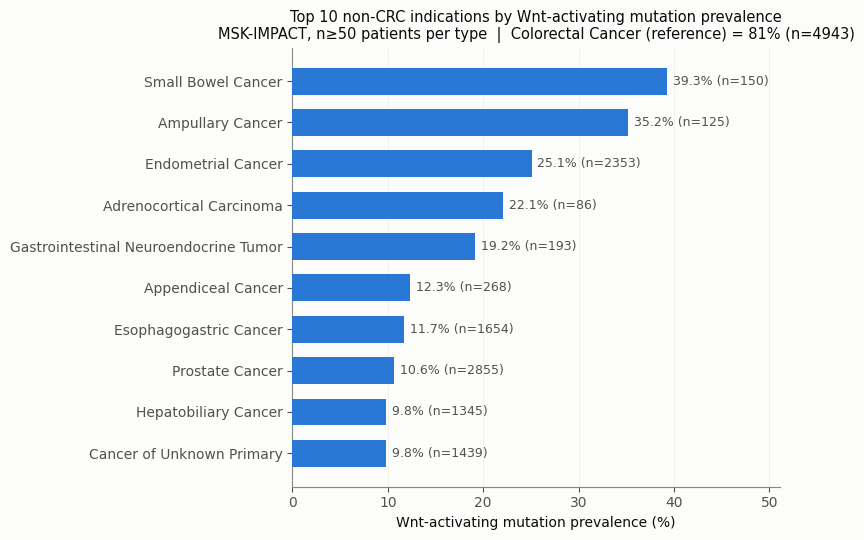

In [11]:
non_crc = prevalence_stable[prevalence_stable.index != "Colorectal Cancer"]
top_non_crc = non_crc.head(10).iloc[::-1]  # reverse for horizontal bar (largest at top)
crc_row = prevalence_stable.loc["Colorectal Cancer"]

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.barh(top_non_crc.index, top_non_crc["prevalence_pct"], color=COLOR_WT, height=0.65, zorder=3)
for y, (idx, row) in enumerate(top_non_crc.iterrows()):
    ax.text(row["prevalence_pct"] + 0.6, y, f"{row['prevalence_pct']:.1f}% (n={int(row['n_total'])})",
            va="center", fontsize=9, color=INK_SECONDARY)

ax.set_xlabel("Wnt-activating mutation prevalence (%)")
ax.set_title(
    "Top 10 non-CRC indications by Wnt-activating mutation prevalence\n"
    f"MSK-IMPACT, n≥50 patients per type  |  Colorectal Cancer (reference) = "
    f"{crc_row['prevalence_pct']:.0f}% (n={int(crc_row['n_total'])})",
    fontsize=10.5,
)
ax.grid(axis="x", linewidth=0.5, alpha=0.6, zorder=0)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.set_xlim(0, top_non_crc["prevalence_pct"].max() * 1.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "wnt_prevalence_by_cancer_type.png", dpi=300, bbox_inches="tight")
plt.show()

### Result: Endometrial Cancer Is the Strongest Candidate for Indication Expansion 

**Cohort:** 48,179 patients (deduplicated, one sample/patient by highest coverage), spanning 64
cancer types. **6,492 patients (13.5%)** carry a Wnt-activating mutation (APC/CTNNB1/RNF43) by
the criteria defined above, applied directly to variant-level MSK-IMPACT data.

**Colorectal Cancer is the reference indication:** 81.0% prevalence (4,006/4,943) — consistent with
Wnt-pathway activation's established role as a near-universal initiating event in CRC.

**Indication-expansion signal — top non-CRC cancer types by prevalence (n≥50 patients each):**

| Cancer type | Prevalence | n |
|---|---|---|
| Small Bowel Cancer | 39.3% | 150 |
| Ampullary Cancer | 35.2% | 125 |
| Endometrial Cancer | 25.1% | 2,353 |
| Adrenocortical Carcinoma | 22.1% | 86 |
| GI Neuroendocrine Tumor | 19.2% | 193 |
| Appendiceal Cancer | 12.3% | 268 |
| Esophagogastric Cancer | 11.7% | 1,654 |
| Prostate Cancer | 10.6% | 2,855 |
| Hepatobiliary Cancer | 9.8% | 1,345 |
| Cancer of Unknown Primary | 9.8% | 1,439 |

**Interpretation:**

- The top two non-CRC indications — **Small Bowel Cancer and Ampullary Cancer** — are
  anatomically and embryologically adjacent to the colon (upper/mid GI tract adenocarcinomas)
  and share overlapping mutational landscapes with CRC in the literature, so a high Wnt-mutation
  rate here is biologically consistent. Sample sizes are modest (125–150)
  relative to CRC's ~5,000, so these estimates carry uncertainty.
- **Endometrial Cancer** is an indication-expansion candidate: a substantial 25.1%
  prevalence at a **large, well-powered sample size (n=2,353)** — this combination of a sizeable
  effect and a large denominator makes it the most statistically robust non-CRC signal in this
  analysis. This also has independent literature support: CTNNB1 exon 3 mutations are a
  well-documented feature of endometrioid-subtype endometrial cancer.
- **Adrenocortical Carcinoma and GI Neuroendocrine Tumor May Warrant Follow-up** Both show high prevalence (22.1%, 19.2%) but with small denominators (n=86, n=193).

**TCF7L2 (broad definition, IMPACT341 excluded from denominator, n=45,843):** 2.4% prevalence
overall; by far the highest in **Colorectal Cancer (15.1%, n=4,763)**, with all other indications
under 6.5%. Because TCF7L2's mutation definition here is broader (any coding mutation, not a
hotspot/truncating standard) and it was not part of the composite Wnt-activating flag, this
is a supplementary observation aligned with the functional-genomics TCF7L2
dependency finding above.

**Credentialing read (patient genomics only):** Endometrial Cancer is the strongest
indication-expansion candidate emerging from patient genomics with large sample, substantial
prevalence, independent literature support. Small Bowel/Ampullary Cancer are directionally
supportive but smaller and noisier. This is one of two evidence lines for the Wnt-pathway
hypothesis; the next section integrates this with the functional-dependency result above
(CTNNB1/TCF7L2 strongly supported, AXIN2 weakly, AXIN1 not) to identify which indication/gene
combinations are supported by both lines of evidence.

### Hypothesis Evaluation

**Indication ranking.** **Endometrial Cancer is the primary indication-expansion candidate**:
25.1% Wnt-activating mutation prevalence with a well-powered sample size (n=2,353), supported
by literature establishing CTNNB1 exon 3 mutation as a recurrent feature of
endometrioid-subtype endometrial cancer.
**Small Bowel Cancer (39.3%, n=150) and Ampullary Cancer (35.2%, n=125) are secondary,
biologically plausible candidates**. Their higher raw prevalence is consistent with
their anatomic/embryologic proximity to the colon, but both cohorts have smaller sample sizes.

**Evidence integration**, classifying each gene as supported by functional-genomics,
patient-genomics, or both:

| Gene | Functional-genomics-supported | Patient-genomics-supported | Supported by both |
|---|---|---|---|
| **CTNNB1** | Yes (r=0.70, q≈10⁻³⁷) | Yes, defines the Wnt-activating biomarker; literature-validated driver in endometrial cancer | **Yes** |
| **TCF7L2** | Yes (r=0.57, q≈10⁻²⁵) | Indirect, with dependency conferred by the APC/CTNNB1/RNF43 biomarker, not its own mutation status| **Yes, via the biomarker** |
| **AXIN2** | Weak (r=0.14, q=0.016) | Not separately assessed | Secondary |
| **AXIN1** | No (q=0.53) | Not separately assessed | Not supported |

**Conclusion:** CTNNB1 in endometrial cancer is the best-credentialed near-term hypothesis — the same gene defines the patient-selection biomarker and shows the strongest functional dependency. TCF7L2 is credentialed too, but by a different logic: it's rarely mutated outside CRC, so a TCF7L2-directed therapy would need to select patients on the composite Wnt-activating biomarker, not TCF7L2 status itself. **Recommendation: prioritize CTNNB1/TCF7L2 dependency in Wnt-activating-mutant endometrial cancer**, with Small Bowel/Ampullary Cancer as secondary indications for further exploration.

## ERG/AR: Does Fusion Status Track with AR-Pathway Alteration?

This analysis is based on TCGA PRAD **patient genomics alone**. A functional genomics comparison (CRISPR
dependency by TMPRSS2-ERG fusion status) was considered but is not included: DepMap does not
provide usable fusion calls for this gene pair, and a
literature-based classification (VCaP as fusion-positive vs. LNCaP/PC3/DU145 as
fusion-negative) would yield a small dataset (one cell line vs three).

### Method: Defining Fusion-Positive and Fusion-Negative Groups

- **Fusion-positive group**: TCGA PRAD's curated `SUBTYPE` field, category `1-ERG` (n=152/333,
  45.6%) — this corresponds directly to ERG-fusion-positive tumors and is consistent with the
  dataset's own structural variant calls (152 `ERG fusion` SV records against 152 `1-ERG`
  subtype patients).
- **Fusion-negative group**: `SUBTYPE` in `{5-SPOP, 8-other}` (n=123) — deliberately **excluding
  ETV1/ETV4/FLI1** subtypes, since those are also fusion-driven (different fusion partners than
  ERG) and would contaminate a clean fusion-vs-non-fusion contrast; and excluding FOXA1/IDH1 as
  neither fusion-driven nor part of the designated non-fusion-driven reference set.
- **AR-pathway status**: AR-V7 presence (binary; Fisher's exact test) and AR Score (continuous;
  Mann-Whitney U), both taken directly from the curated sample-level fields — more specific and
  clinically meaningful than a generic amplification/mutation flag, given AR-V7's established
  role in treatment resistance.

In [12]:
tcga_patient = pd.read_csv(
    DATA_DIR / "TCGA_PRAD_clinical_patient.txt", sep="\t", comment="#",
    usecols=["PATIENT_ID", "SUBTYPE"],
)
tcga_sample = pd.read_csv(
    DATA_DIR / "TCGA_PRAD_clinical_sample.txt", sep="\t", comment="#",
    usecols=["SAMPLE_ID", "PATIENT_ID", "AR_SCORE", "AR_V7_PRESENCE"],
)
tcga = tcga_patient.merge(tcga_sample, on="PATIENT_ID", how="inner")
assert len(tcga) == 333

tcga["fusion_group"] = np.select(
    [tcga["SUBTYPE"] == "1-ERG", tcga["SUBTYPE"].isin(["5-SPOP", "8-other"])],
    ["fusion_positive", "fusion_negative"],
    default=None,
)
tcga_erg = tcga.dropna(subset=["fusion_group"]).copy()
print(tcga_erg["fusion_group"].value_counts())

fusion_group
fusion_positive    152
fusion_negative    123
Name: count, dtype: int64


In [13]:
# AR-V7 presence: Fisher's exact test
ar_v7_ct = pd.crosstab(tcga_erg["fusion_group"], tcga_erg["AR_V7_PRESENCE"])
odds_ratio, p_fisher = stats.fisher_exact(ar_v7_ct)

print("AR-V7 presence contingency table:")
print(ar_v7_ct)
print(f"\nFisher's exact test: OR = {odds_ratio:.2f}, p = {p_fisher:.3f}")

for grp in ["fusion_positive", "fusion_negative"]:
    pct = 100 * tcga_erg.loc[tcga_erg["fusion_group"] == grp, "AR_V7_PRESENCE"].mean()
    print(f"  AR-V7+ in {grp}: {pct:.1f}%")

AR-V7 presence contingency table:
AR_V7_PRESENCE     0   1
fusion_group            
fusion_negative   90  33
fusion_positive  117  35

Fisher's exact test: OR = 0.82, p = 0.485
  AR-V7+ in fusion_positive: 23.0%
  AR-V7+ in fusion_negative: 26.8%


In [14]:
# AR Score: Mann-Whitney U test
ar_score_pos = tcga_erg.loc[tcga_erg["fusion_group"] == "fusion_positive", "AR_SCORE"].dropna()
ar_score_neg = tcga_erg.loc[tcga_erg["fusion_group"] == "fusion_negative", "AR_SCORE"].dropna()

u_stat, p_mw = stats.mannwhitneyu(ar_score_pos, ar_score_neg, alternative="two-sided")
# Rank-biserial: r > 0 means fusion_positive scores tend to be LOWER than fusion_negative
# (same convention verified in the Wnt-pathway analysis above).
r_rb = 1 - (2 * u_stat) / (len(ar_score_pos) * len(ar_score_neg))

print(f"AR Score — fusion-positive: n={len(ar_score_pos)}, median={ar_score_pos.median():.2f}")
print(f"AR Score — fusion-negative: n={len(ar_score_neg)}, median={ar_score_neg.median():.2f}")
print(f"\nMann-Whitney U test: p = {p_mw:.2e}, rank-biserial r = {r_rb:.2f}")

AR Score — fusion-positive: n=152, median=-1.79
AR Score — fusion-negative: n=123, median=3.25

Mann-Whitney U test: p = 4.90e-08, rank-biserial r = 0.38


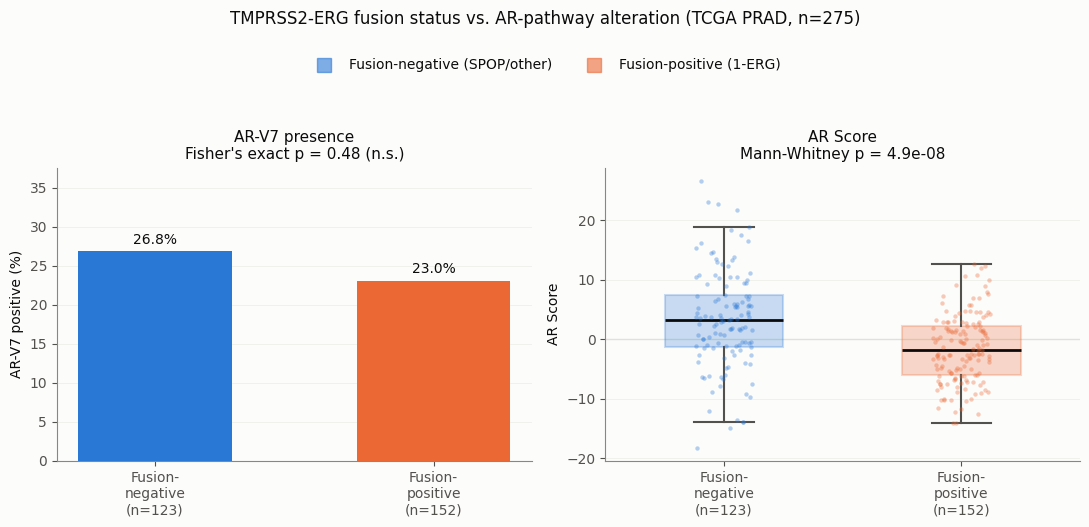

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Panel 1: AR-V7 presence, grouped bar
groups = ["fusion_negative", "fusion_positive"]
group_labels = [f"Fusion-\nnegative\n(n={(tcga_erg.fusion_group=='fusion_negative').sum()})",
                f"Fusion-\npositive\n(n={(tcga_erg.fusion_group=='fusion_positive').sum()})"]
colors = [COLOR_WT, COLOR_MUTANT]
ar_v7_pct = [100 * tcga_erg.loc[tcga_erg["fusion_group"] == g, "AR_V7_PRESENCE"].mean() for g in groups]

bars = ax1.bar(group_labels, ar_v7_pct, color=colors, width=0.55, zorder=3)
for bar, pct in zip(bars, ar_v7_pct):
    ax1.text(bar.get_x() + bar.get_width() / 2, pct + 1, f"{pct:.1f}%", ha="center", fontsize=10, color=INK_PRIMARY)
ax1.set_ylabel("AR-V7 positive (%)")
ax1.set_title(f"AR-V7 presence\nFisher's exact p = {p_fisher:.2f} (n.s.)", fontsize=11)
ax1.set_ylim(0, max(ar_v7_pct) * 1.4)
ax1.grid(axis="y", linewidth=0.5, alpha=0.6, zorder=0)
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)

# Panel 2: AR Score, boxplot + jitter
bp = ax2.boxplot(
    [ar_score_neg, ar_score_pos], positions=[0, 1], widths=0.5, patch_artist=True, showfliers=False,
    medianprops=dict(color=INK_PRIMARY, linewidth=2), boxprops=dict(linewidth=1.5),
    whiskerprops=dict(linewidth=1.5, color=INK_SECONDARY), capprops=dict(linewidth=1.5, color=INK_SECONDARY),
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.25)
    patch.set_edgecolor(color)

rng = np.random.default_rng(0)
for x, scores, color in zip([0, 1], [ar_score_neg, ar_score_pos], colors):
    jitter = rng.uniform(-0.12, 0.12, size=len(scores))
    ax2.scatter(x + jitter, scores, s=10, color=color, alpha=0.35, linewidths=0, zorder=3)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(group_labels)
ax2.set_ylabel("AR Score")
ax2.set_title(f"AR Score\nMann-Whitney p = {p_mw:.1e}", fontsize=11)
ax2.axhline(0, color=GRID, linewidth=1, zorder=0)
ax2.grid(axis="y", linewidth=0.5, alpha=0.6, zorder=0)
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

handles = [
    plt.Line2D([0], [0], marker="s", linestyle="", markerfacecolor=COLOR_WT, markeredgecolor=COLOR_WT, alpha=0.6, markersize=10, label="Fusion-negative (SPOP/other)"),
    plt.Line2D([0], [0], marker="s", linestyle="", markerfacecolor=COLOR_MUTANT, markeredgecolor=COLOR_MUTANT, alpha=0.6, markersize=10, label="Fusion-positive (1-ERG)"),
]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False)
fig.suptitle("TMPRSS2-ERG fusion status vs. AR-pathway alteration (TCGA PRAD, n=275)", y=1.16, fontsize=12)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "erg_ar_cooccurrence.png", dpi=300, bbox_inches="tight")
plt.show()

### Result: AR Score Differs by Fusion Status, AR-V7 Presence Does Not

**Cohort:** 275 TCGA PRAD patients (152 fusion-positive `1-ERG`, 123 fusion-negative
`SPOP`/`other`).

- **AR-V7 presence does not differ by fusion status.** 23.0% of fusion-positive tumors vs. 26.8%
  of fusion-negative tumors are AR-V7+ (Fisher's exact OR = 0.82, p = 0.48) — no evidence of
  association. This is a clean null result on a well-powered binary comparison. TCGA PRAD is a primary/localized-disease cohort, whereas AR-V7 is an established marker of treatment-resistant, typically metastatic/castration-resistant disease —so a null result here is consistent with what the cohort's disease stage would predict.
- **AR Score differs significantly by fusion status.** Fusion-negative tumors have a
  much higher AR Score (median 3.25) than fusion-positive tumors (median −1.79) — Mann-Whitney
  p = 4.9×10⁻⁸, rank-biserial r = 0.38 (moderate-to-large effect on a well-powered n). ERG-fusion
  tumors show a *lower* overall AR transcriptional output signature than the SPOP-mutant/other
  reference group.

**Interpretation:** this dataset shows fusion status tracks with *quantitative*
AR transcriptional activity (AR Score) but not with the specific *AR-V7 splice-variant*
biomarker. AR-V7 is one specific, clinically-actionable readout of AR pathway activity
(associated with treatment resistance) while AR Score is a broader transcriptional signature.
These readouts are two different facets of AR pathway status. Further investigation in additional cohorts is warranted to address mechanistic relationship betwee fusion status and AR patwhay activity.

### Synthesis: Patient Stratification Signal

TMPRSS2-ERG fusion status is significantly associated with lower AR transcriptional output (AR Score, p=4.9×10⁻⁸) but not with AR-V7 presence (p=0.48). This suggests ERG-fusion status and AR-pathway activity intensity are partially independent axes of molecular subtype — fusion status shifts the AR Score distribution without fully separating from it. A combination trial would likely need fusion status and AR Score as two separate stratification factors.

This analysis used patient genomics alone, since no usable functional dependency data was available for TMPRSS2-ERG fusion status.

## Discussion

### What this comparison shows
The same credentialing framework of integrating functional and patient genomics evidence performed differently across the two analyses. The Wnt-pathway analysis had two independent, well-powered evidence lines, and integrating them separated CTNNB1 (supported by both, same indication) from TCF7L2 (strong functional evidence, but indirect support in patient genomic data) from AXIN1/AXIN2 (weak/null). The ERG/AR analysis could only use one evidence line, since no usable public functional dependency data exist for TMPRSS2-ERG fusion status; the patient genomics finding is well-powered (n=275, p=4.9×10⁻⁸).

Public data constraints: The limiting factor in a real-world credentialing exercise is rarely statistical method — it's data availability. Knowing when to substitute a comparably rigorous alternative, and being explicit about the resulting asymmetry in evidentiary strength, matters more than any single test.

### Limitations:

    -Prevalence estimates for smaller cancer types (Ampullary Cancer, n=125) are less statistically stable than for larger ones. 
    -TCGA PRAD's total cohort (n=333) is far smaller than MSK-IMPACT's (n=48,179), so the ERG/AR findings are on fewer samples.
    -TCGA PRAD has deeper curation at the cost of real-world representativeness; MSK-IMPACT has real-world scale at the cost of that curation depth. 
    -ERG-fusion status is derived from TCGA's curated molecular subtype field, which is in agreement with the dataset's structural variant calls (152/152).
    -DepMap's mutation flags rely on precomputed classifications, since no variant-level data were available; MSK-IMPACT's flags were verified directly against variant-level codon positions. The calls are conceptually equivalent but not methodologically identical.
    -Scope excludes structural/protein-protein interaction modeling, de novo CRISPR screen analysis, and real-world clinical/EHR outcomes data (not publicly accessible without institutional affiliation). The ERG/AR analysis is limited to patient genomics only, for the same data-availability reasons.


